In [1]:
import pandas as pd

from sklearn.linear_model import SGDClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

In [2]:
file_name = 'cleaned_text_file.csv' # Assuming this is the file you want to process locally
# uploaded = files.upload() # Removed Colab-specific upload
# file_name = list(uploaded.keys())[0]
print(file_name)
df = pd.read_csv(file_name)
print(df.head())

cleaned_text_file.csv
                                        cleaned_text sentiment
0  accord gran company plan move production russi...   neutral
1  last quarter componenta net sale double eurm e...  positive
2  third quarter net sale increase percentage eur...  positive
3  operating profit rise eurmarket neutralfrom eu...  positive
4  operating profit total eurmarket neutralup eur...  positive


In [3]:
print("Dataset shape:", df.shape)
df.dropna(subset=['cleaned_text'], inplace=True)
print("Dataset shape:", df.shape)
print("\nClass distribution:")
print(df['sentiment'].value_counts())

Dataset shape: (2264, 2)
Dataset shape: (2263, 2)

Class distribution:
sentiment
neutral     1390
positive     570
negative     303
Name: count, dtype: int64


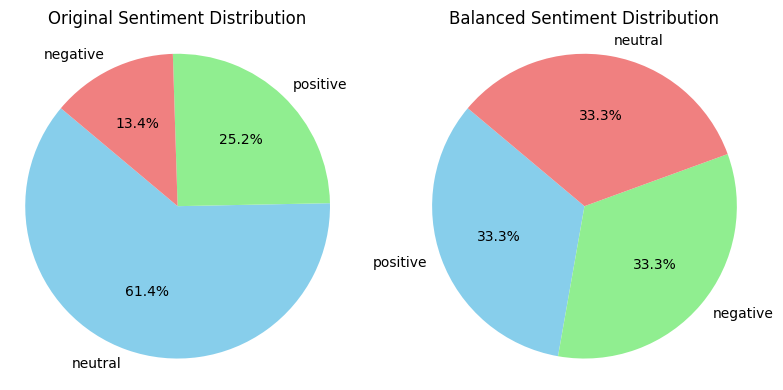

sentiment
neutral     1390
positive     570
negative     303
Name: count, dtype: int64
sentiment
positive    570
negative    570
neutral     570
Name: count, dtype: int64


In [4]:
import matplotlib.pyplot as plt
from sklearn.utils import resample
import pandas as pd

# --- Original Distribution ---
sentiment_counts = df['sentiment'].value_counts()

# --- Balancing the dataset (upsampling minority classes) ---
df_majority = df[df.sentiment == 'positive']  # majority (~46%)
df_minority1 = df[df.sentiment == 'negative']
df_minority2 = df[df.sentiment == 'neutral']

# Upsample minority classes to match the majority class size
df_minority1_upsampled = resample(df_minority1, replace=True, n_samples=len(df_majority), random_state=42)
df_minority2_upsampled = resample(df_minority2, replace=True, n_samples=len(df_majority), random_state=42)

# Combine them
df_balanced = pd.concat([df_majority, df_minority1_upsampled, df_minority2_upsampled])

# --- Balanced Distribution ---
sentiment_counts_balanced = df_balanced['sentiment'].value_counts()

# --- Side-by-side pie charts ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Left pie: Original distribution
axes[0].pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%',
            startangle=140, colors=['skyblue', 'lightgreen', 'lightcoral'])
axes[0].set_title('Original Sentiment Distribution')
axes[0].axis('equal')

# Right pie: Balanced distribution
axes[1].pie(sentiment_counts_balanced, labels=sentiment_counts_balanced.index, autopct='%1.1f%%',
            startangle=140, colors=['skyblue', 'lightgreen', 'lightcoral'])
axes[1].set_title('Balanced Sentiment Distribution')
axes[1].axis('equal')

plt.tight_layout()
plt.show()

print(sentiment_counts)
print(sentiment_counts_balanced)


In [5]:
df=df_balanced

In [6]:
# Prepare features and labels
X = df['cleaned_text']
y = df['sentiment'] # as "positive""negative""neutral"

# First split: separate test set (80% train+val, 20% test)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Second split: separate validation set (75% train, 25% val of the temp set)
# This gives us 60% train, 20% val, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("\nData split sizes:")
print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")

# Vectorize the text using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)
X_test_vec = vectorizer.transform(X_test)

print(f"\nFeature matrix shape: {X_train_vec.shape}")


Data split sizes:
Training set: 1026 samples
Validation set: 342 samples
Test set: 342 samples

Feature matrix shape: (1026, 5000)


**Linear** **Regression**

Training SGDClassifier model...
--------------------------------------------------
Epoch 1/8
  Train Loss: 0.1628 | Train Acc: 0.9552
  Val Loss: 0.7919 | Val Acc: 0.7665
--------------------------------------------------
Epoch 2/8
  Train Loss: 0.0567 | Train Acc: 0.9931
  Val Loss: 0.6700 | Val Acc: 0.7885
--------------------------------------------------
Epoch 3/8
  Train Loss: 0.0420 | Train Acc: 0.9976
  Val Loss: 0.6157 | Val Acc: 0.7983
--------------------------------------------------
Epoch 4/8
  Train Loss: 0.0413 | Train Acc: 0.9984
  Val Loss: 0.5902 | Val Acc: 0.8020
--------------------------------------------------
Epoch 5/8
  Train Loss: 0.0447 | Train Acc: 0.9988
  Val Loss: 0.5698 | Val Acc: 0.7995
--------------------------------------------------
Epoch 6/8
  Train Loss: 0.0481 | Train Acc: 0.9988
  Val Loss: 0.5577 | Val Acc: 0.7983
--------------------------------------------------
Epoch 7/8
  Train Loss: 0.0510 | Train Acc: 0.9988
  Val Loss: 0.5498 | Val Acc: 0.

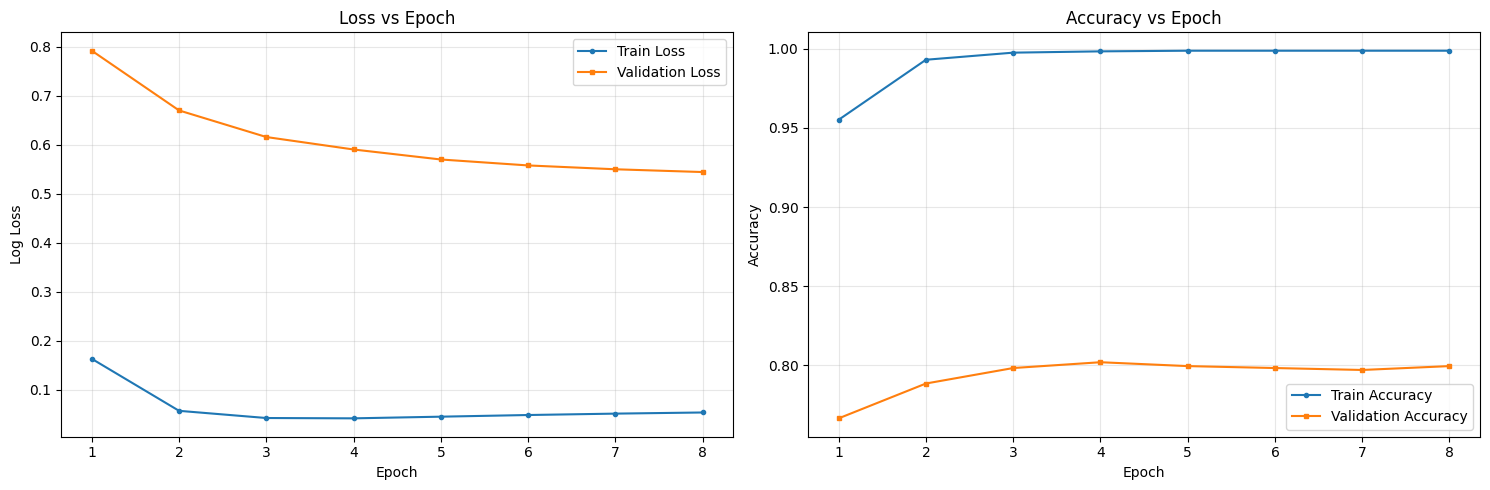

In [ ]:
from sklearn.metrics import log_loss
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight


# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
epochs_list = []

sgd = SGDClassifier(
    loss='log_loss',      # logistic regression loss
    max_iter=1,
    learning_rate='optimal',
    l1_ratio=0.15,
    random_state=42,
    penalty='elasticnet',
    # class_weight='balanced', # Remove this line
    alpha=0.00001,
    warm_start=True
)

epochs = 8  # Set a reasonable number of epochs for training

# Get unique classes for partial_fit
classes = np.unique(y_train)

# Compute class weights manually
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))


print("Training SGDClassifier model...")
print("-" * 50)

for epoch in range(epochs):  # Train for a specified number of epochs
    # Train for one epoch, passing the computed class weights
    sgd.partial_fit(X_train_vec, y_train, classes=classes, sample_weight=np.array([class_weight_dict[label] for label in y_train]))


    # Predictions for accuracy
    y_train_pred = sgd.predict(X_train_vec)
    y_val_pred = sgd.predict(X_val_vec)

    # Calculate accuracies
    train_acc = sgd.score(X_train_vec, y_train)
    val_acc = sgd.score(X_val_vec, y_val)

    # Get predicted probabilities for loss calculation
    y_train_proba = sgd.predict_proba(X_train_vec)
    y_val_proba = sgd.predict_proba(X_val_vec)

    # Calculate log loss
    train_loss = log_loss(y_train, y_train_proba)
    val_loss = log_loss(y_val, y_val_proba)


    # Store metrics
    epochs_list.append(epoch + 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)


    # Print progress
    if (epoch + 1) % 1 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        print("-" * 50)

print("\nTraining completed!")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
axes[0].plot(epochs_list, train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(epochs_list, val_losses, label='Validation Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(epochs_list, train_accuracies, label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(epochs_list, val_accuracies, label='Validation Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**LogisticRegression**

Training LogisticRegression model...
--------------------------------------------------
Epoch 1/80
  Train Loss: 0.9466 | Train Acc: 0.7876
  Val Loss: 0.9715 | Val Acc: 0.6479
Epoch 2/80
  Train Loss: 0.9372 | Train Acc: 0.6686
  Val Loss: 0.9600 | Val Acc: 0.6296
Epoch 3/80
  Train Loss: 0.9276 | Train Acc: 0.6975
  Val Loss: 0.9606 | Val Acc: 0.5905
Epoch 4/80
  Train Loss: 0.9091 | Train Acc: 0.7256
  Val Loss: 0.9381 | Val Acc: 0.6479
Epoch 5/80
  Train Loss: 0.8929 | Train Acc: 0.7705
  Val Loss: 0.9312 | Val Acc: 0.6540
Epoch 6/80
  Train Loss: 0.8815 | Train Acc: 0.7615
  Val Loss: 0.9168 | Val Acc: 0.6675
Epoch 7/80
  Train Loss: 0.8705 | Train Acc: 0.7244
  Val Loss: 0.9151 | Val Acc: 0.6345
Epoch 8/80
  Train Loss: 0.8554 | Train Acc: 0.7807
  Val Loss: 0.8969 | Val Acc: 0.6907
Epoch 9/80
  Train Loss: 0.8394 | Train Acc: 0.7746
  Val Loss: 0.8896 | Val Acc: 0.6614
Epoch 10/80
  Train Loss: 0.8298 | Train Acc: 0.7962
  Val Loss: 0.8775 | Val Acc: 0.6980
Epoch 11/80
  Train L

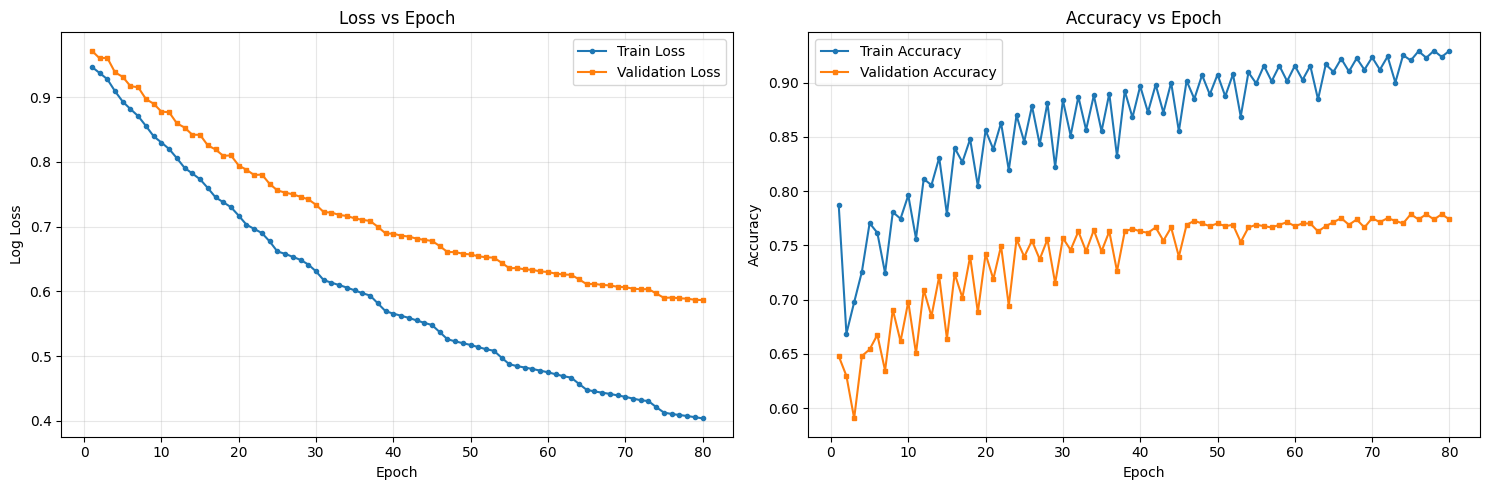

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.utils.class_weight import compute_class_weight

# Initialize lists to store metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
epochs_list = []

# Compute class weights manually
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Initialize logistic regression model
log_reg = LogisticRegression(
    solver='lbfgs',           # supports elasticnet + warm_start
    # penalty='elasticnet',
    # l1_ratio=0.15,
    C=1/0.000001,             # inverse of alpha used in SGD
    # class_weight=class_weight_dict,
    max_iter=1,              # one iteration per epoch
    warm_start=True,
    random_state=42
)

epochs = 80
print("Training LogisticRegression model...")
print("-" * 50)

for epoch in range(epochs):
    # Train model for one epoch
    log_reg.fit(X_train_vec, y_train)

    # Predictions
    y_train_pred = log_reg.predict(X_train_vec)
    y_val_pred = log_reg.predict(X_val_vec)

    # Accuracies
    train_acc = log_reg.score(X_train_vec, y_train)
    val_acc = log_reg.score(X_val_vec, y_val)

    # Probabilities for log loss
    y_train_proba = log_reg.predict_proba(X_train_vec)
    y_val_proba = log_reg.predict_proba(X_val_vec)

    # Losses
    train_loss = log_loss(y_train, y_train_proba)
    val_loss = log_loss(y_val, y_val_proba)

    # Store metrics
    epochs_list.append(epoch + 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    # Print progress
    print(f"Epoch {epoch + 1}/{epochs}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")


print("\nTraining completed!")

# --- Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot Loss
axes[0].plot(epochs_list, train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(epochs_list, val_losses, label='Validation Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot Accuracy
axes[1].plot(epochs_list, train_accuracies, label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(epochs_list, val_accuracies, label='Validation Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy vs Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# @title
# Train the SGDClassifier with 'hinge' loss (SVM) and monitor loss
losses = []
svm = SGDClassifier(
    loss='hinge',  # Hinge loss for SVM
    max_iter=1, # Set max_iter to 1 for training one epoch at a time
    learning_rate='optimal',
    random_state=42,
    warm_start=True # Keep the model state between fits
)

epochs = 100 # Number of epochs to train for

for epoch in range(epochs):
    svm.fit(X_train_vec, y_train)

    # Calculate loss on the validation set
    # Note: SGDClassifier with 'hinge' loss doesn't directly provide predict_proba for multi-class
    # We will use the decision_function and average hinge loss
    decision_values = svm.decision_function(X_val_vec)
    # Convert y_val to numerical labels based on svm.classes_
    label_map = {label: i for i, label in enumerate(svm.classes_)}
    y_val_numeric = y_val.map(label_map).values

    # Calculate hinge loss: max(0, 1 - y_true * decision_value)
    # For multi-class, hinge loss is max(0, 1 - decision_value_correct_class + decision_value_other_class_max)
    # A common way to approximate this for plotting is to use the margin: y_true * decision_value
    # We'll use a simplified approach by considering the margin of the correct class
    # This is not the exact multi-class hinge loss but can give an indication of convergence
    hinge_loss = np.maximum(0, 1 - decision_values[np.arange(len(y_val_numeric)), y_val_numeric])
    loss = np.mean(hinge_loss)

    losses.append(loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")


plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Approximate Hinge Loss (Validation Set)')
plt.title('Loss per Epoch during SVM Training')
plt.show()

print("Training complete.")

**RandomForest**

Training Random Forest with incremental trees...
Trees: 1/50, Train Loss: 3.6535, Val Loss: 10.8553
Trees: 2/50, Train Loss: 0.6783, Val Loss: 4.1467
Trees: 3/50, Train Loss: 0.3086, Val Loss: 2.5399
Trees: 4/50, Train Loss: 0.2410, Val Loss: 2.0136
Trees: 5/50, Train Loss: 0.1667, Val Loss: 1.4307
Trees: 6/50, Train Loss: 0.1318, Val Loss: 1.4268
Trees: 7/50, Train Loss: 0.1305, Val Loss: 1.1366
Trees: 8/50, Train Loss: 0.1286, Val Loss: 1.1457
Trees: 9/50, Train Loss: 0.1268, Val Loss: 0.9448
Trees: 10/50, Train Loss: 0.1238, Val Loss: 0.8454
Trees: 11/50, Train Loss: 0.1219, Val Loss: 0.8514
Trees: 12/50, Train Loss: 0.1209, Val Loss: 0.8536
Trees: 13/50, Train Loss: 0.1189, Val Loss: 0.8477
Trees: 14/50, Train Loss: 0.1188, Val Loss: 0.8397
Trees: 15/50, Train Loss: 0.1178, Val Loss: 0.8369
Trees: 16/50, Train Loss: 0.1166, Val Loss: 0.8383
Trees: 17/50, Train Loss: 0.1165, Val Loss: 0.7483
Trees: 18/50, Train Loss: 0.1161, Val Loss: 0.7445
Trees: 19/50, Train Loss: 0.1159, Val Los

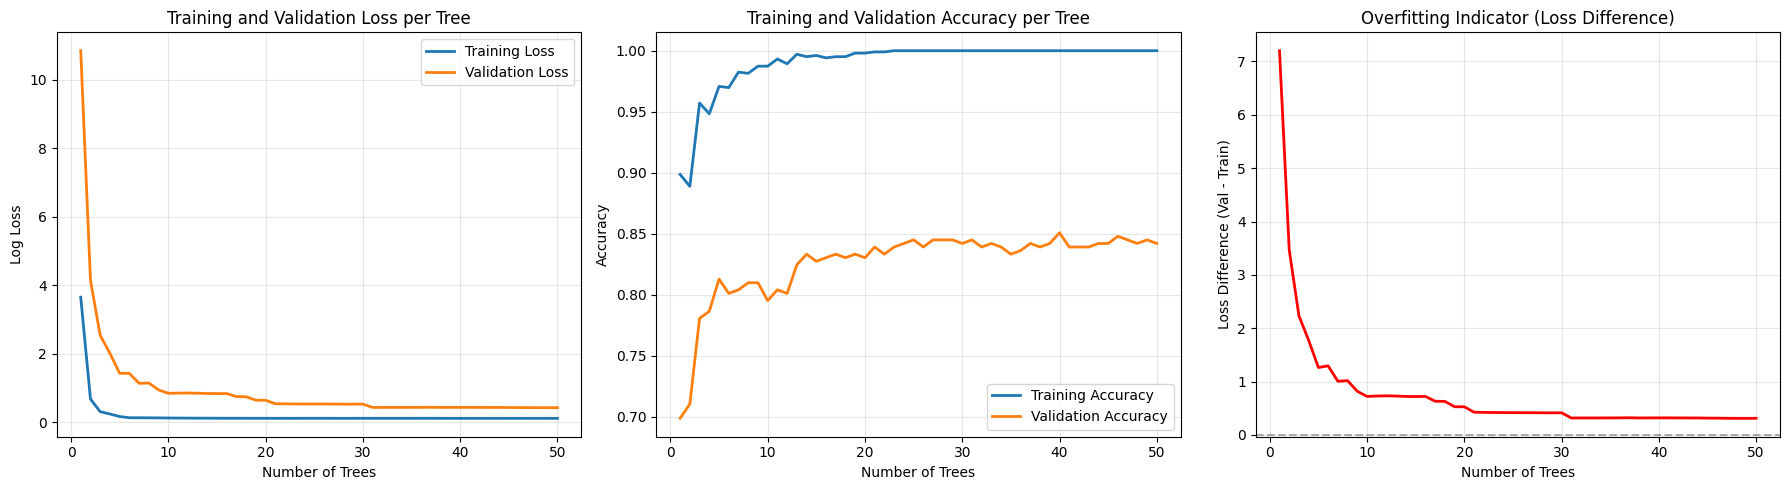


Optimal number of trees (based on minimum validation loss): 49
Minimum validation loss: 0.4253

Optimal number of trees (based on maximum validation accuracy): 40
Maximum validation accuracy: 0.8509

Final Model Performance (with 50 trees):
Training Accuracy: 1.0000
Validation Accuracy: 0.8421
Test Accuracy: 0.8275


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss
# Initialize lists to store losses and accuracies
train_losses = []
val_losses = []
train_accuracies = [] # Add list for train accuracy
val_accuracies = []  # Add list for val accuracy

# Train Random Forest with incremental estimators
rf = RandomForestClassifier(
    n_estimators=1,  # Start with 1 tree
    random_state=42,
    warm_start=True,  # Keep previous trees when adding new ones
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    n_jobs=-1  # Use all available cores
)

max_estimators = 50  # Total number of trees to train

print("Training Random Forest with incremental trees...")

for n_trees in range(1, max_estimators + 1):
    # Set the number of estimators
    rf.n_estimators = n_trees

    # Fit the model (warm_start ensures we only add new trees)
    rf.fit(X_train_vec, y_train)

    # Get predicted probabilities for loss calculation
    train_proba = rf.predict_proba(X_train_vec)
    val_proba = rf.predict_proba(X_val_vec)

    # Calculate log loss (cross-entropy loss)
    train_loss = log_loss(y_train, train_proba)
    val_loss = log_loss(y_val, val_proba)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # Calculate and store accuracies
    train_acc = rf.score(X_train_vec, y_train)
    val_acc = rf.score(X_val_vec, y_val)
    train_accuracies.append(train_acc) # Store train accuracy
    val_accuracies.append(val_acc)   # Store val accuracy


    if n_trees % 1 == 0:
        print(f"Trees: {n_trees}/{max_estimators}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        # print(f"Trees: {n_trees}/{max_estimators}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}") # Optional: Print accuracies too


print("\nTraining complete.")

# Plot Training and Validation Loss and Accuracy
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Create space for 3 plots

# Plot 1: Training and Validation Loss
axes[0].plot(range(1, max_estimators + 1), train_losses, label='Training Loss', linewidth=2)
axes[0].plot(range(1, max_estimators + 1), val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Training and Validation Loss per Tree')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Training and Validation Accuracy (NEW PLOT)
axes[1].plot(range(1, max_estimators + 1), train_accuracies, label='Training Accuracy', linewidth=2)
axes[1].plot(range(1, max_estimators + 1), val_accuracies, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Number of Trees')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy per Tree')
axes[1].legend()
axes[1].grid(True, alpha=0.3)


# Plot 3: Loss Difference (Overfitting Indicator)
axes[2].plot(range(1, max_estimators + 1), np.array(val_losses) - np.array(train_losses), color='red', linewidth=2)
axes[2].set_xlabel('Number of Trees')
axes[2].set_ylabel('Loss Difference (Val - Train)')
axes[2].set_title('Overfitting Indicator (Loss Difference)')
axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the optimal number of trees (minimum validation loss)
optimal_trees_loss = np.argmin(val_losses) + 1
print(f"\nOptimal number of trees (based on minimum validation loss): {optimal_trees_loss}")
print(f"Minimum validation loss: {val_losses[optimal_trees_loss-1]:.4f}")

# Find the optimal number of trees (maximum validation accuracy)
optimal_trees_acc = np.argmax(val_accuracies) + 1
print(f"\nOptimal number of trees (based on maximum validation accuracy): {optimal_trees_acc}")
print(f"Maximum validation accuracy: {val_accuracies[optimal_trees_acc-1]:.4f}")

# Evaluate the final model
train_acc = rf.score(X_train_vec, y_train)
val_acc = rf.score(X_val_vec, y_val)
test_acc = rf.score(X_test_vec, y_test) # Evaluate on test set too


print(f"\nFinal Model Performance (with {max_estimators} trees):")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.8275

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.87      0.89       114
     neutral       0.77      0.94      0.85       114
    positive       0.82      0.68      0.74       114

    accuracy                           0.83       342
   macro avg       0.83      0.83      0.82       342
weighted avg       0.83      0.83      0.82       342



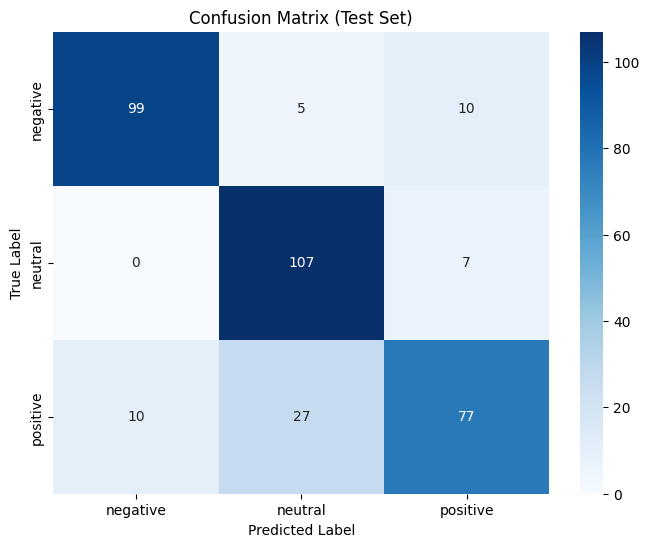

In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Evaluate the final Random Forest model on the test set
test_acc = rf.score(X_test_vec, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

# Get predictions for the test set
y_pred = rf.predict(X_test_vec)

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()

In [9]:
import pickle

# Define the filenames for the model and dictionary
model_filename = 'sentiment_model.pkl'
vectorizer_filename = 'vectorizer.pkl'


# Save the trained model and dictionary
with open(model_filename, 'wb') as f:
    pickle.dump(rf, f) # 'rf' is the RandomForestClassifier from Cell 12

with open(vectorizer_filename, 'wb') as f:
    pickle.dump(vectorizer, f) # 'vectorizer' is the TfidfVectorizer from Cell 5


print(f"Random Forest model saved as '{model_filename}'")
print(f"Vectorizer saved as '{vectorizer_filename}'")

# Download the saved files
# files.download(model_filename) # Removed Colab-specific download
# files.download(vectorizer_filename) # Removed Colab-specific download


print("\nModel and dictionary files are ready for download.")

Random Forest model saved as 'sentiment_model.pkl'
Vectorizer saved as 'vectorizer.pkl'

Model and dictionary files are ready for download.


**SVM**

Training SVM with SGDClassifier...
Epoch 10/100, Train Loss: 0.3049, Val Loss: 0.8893
Epoch 20/100, Train Loss: 0.2466, Val Loss: 0.7844
Epoch 30/100, Train Loss: 0.2817, Val Loss: 0.8496
Epoch 40/100, Train Loss: 0.2868, Val Loss: 0.8397
Epoch 50/100, Train Loss: 0.2773, Val Loss: 0.8514
Epoch 60/100, Train Loss: 0.2546, Val Loss: 0.8067
Epoch 70/100, Train Loss: 0.2718, Val Loss: 0.8386
Epoch 80/100, Train Loss: 0.2850, Val Loss: 0.8854
Epoch 90/100, Train Loss: 0.2619, Val Loss: 0.8298
Epoch 100/100, Train Loss: 0.2540, Val Loss: 0.7902

Training complete.


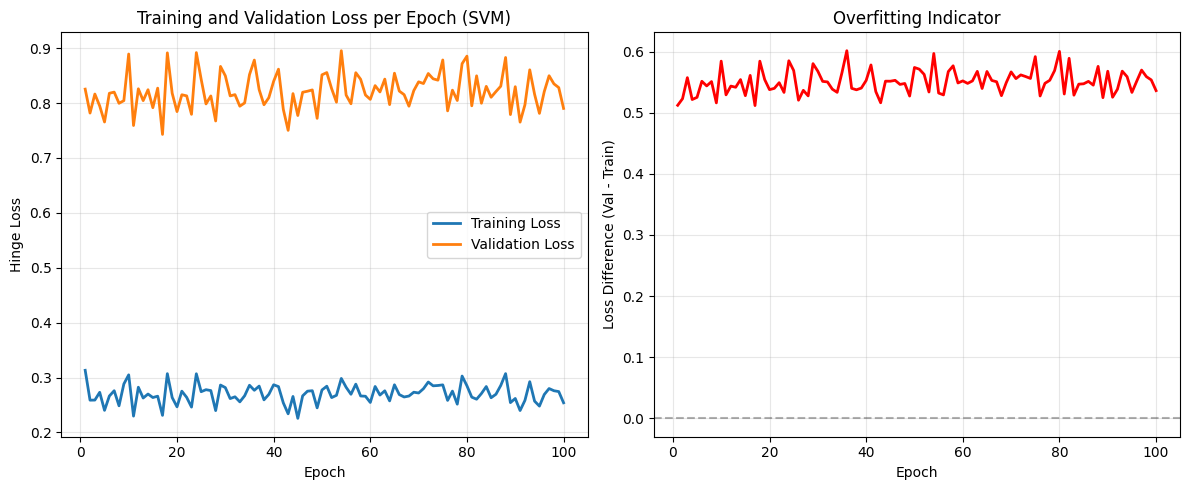


Optimal epoch: 17
Minimum validation loss: 0.7428

Final Model Performance:
Training Accuracy: 0.9343
Validation Accuracy: 0.7379


In [ ]:
from sklearn.linear_model import SGDClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss
import numpy as np

# Initialize lists to store losses
train_losses = []
val_losses = []

# Train the SGDClassifier with 'hinge' loss (SVM) and monitor loss
svm = SGDClassifier(
    loss='hinge',  # Hinge loss for SVM
    max_iter=1,  # Set max_iter to 1 for training one epoch at a time
    learning_rate='optimal',
    random_state=42,
    warm_start=True  # Keep the model state between fits
)

epochs = 100  # Number of epochs to train for

print("Training SVM with SGDClassifier...")

for epoch in range(epochs):
    svm.fit(X_train_vec, y_train)

    # Calculate loss on TRAINING set
    train_decision_values = svm.decision_function(X_train_vec)
    label_map = {label: i for i, label in enumerate(svm.classes_)}
    y_train_numeric = y_train.map(label_map).values

    # Calculate hinge loss for training set
    train_hinge_loss = np.maximum(0, 1 - train_decision_values[np.arange(len(y_train_numeric)), y_train_numeric])
    train_loss = np.mean(train_hinge_loss)
    train_losses.append(train_loss)

    # Calculate loss on VALIDATION set
    val_decision_values = svm.decision_function(X_val_vec)
    y_val_numeric = y_val.map(label_map).values

    # Calculate hinge loss for validation set
    val_hinge_loss = np.maximum(0, 1 - val_decision_values[np.arange(len(y_val_numeric)), y_val_numeric])
    val_loss = np.mean(val_hinge_loss)
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

print("\nTraining complete.")

# Plot Training and Validation Loss
plt.figure(figsize=(12, 5))

# Plot 1: Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', linewidth=2)
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.title('Training and Validation Loss per Epoch (SVM)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Loss Difference (Overfitting Indicator)
plt.subplot(1, 2, 2)
loss_diff = np.array(val_losses) - np.array(train_losses)
plt.plot(range(1, epochs + 1), loss_diff, color='red', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss Difference (Val - Train)')
plt.title('Overfitting Indicator')
plt.axhline(y=0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the optimal epoch (minimum validation loss)
optimal_epoch = np.argmin(val_losses) + 1
print(f"\nOptimal epoch: {optimal_epoch}")
print(f"Minimum validation loss: {val_losses[optimal_epoch-1]:.4f}")

# Evaluate the final model
train_acc = svm.score(X_train_vec, y_train)
val_acc = svm.score(X_val_vec, y_val)

print(f"\nFinal Model Performance:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

In [13]:
# Define the filenames for the model and dictionary
model_filename = 'sentiment_model.pkl'


# Save the trained model and dictionary
joblib.dump(sentiment_model, model_filename)


print(f"Model saved to {model_filename}")


# Download the saved files
files.download(model_filename)


print("\nModel and dictionary files are ready for download.")


NameError: name 'sentiment_model' is not defined